In [347]:
import os
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from tbanalysis import helpers

import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
import uproot
plt.style.use(hep.style.ATLAS)

In [348]:
# load the configuration file
import yaml
with open ("../config.yaml") as c:
    config = yaml.safe_load(c)

In [349]:
campaign = 'data'
year = 2024 # year of data taking
energy = 80 # GeV
angle = 70 # degree
run_number = config['run_info'][year][energy][angle]
center_cell = 'A-3'
hit_cell = config['run_info'][year]['hit_cell']
scan_type = config['run_info'][year]['scan_type']
if scan_type == "theta":
    ang_txt = "θ"
print(f"For {year} data with E={energy} GeV and angle {angle} - Run number is {run_number}. Hit cell is {hit_cell}\n")
print(f"Using cell {center_cell} as hit cell \n")
run_path = f"{config['file_path'][campaign]}/tiletb_{run_number}.root"
save_path = config['file_path']['results']
results_dir = f"{os.getcwd()}/{save_path}/"
os.makedirs(results_dir, exist_ok=True)
print(f"Reading run {run_path} \n")
print(f"Results will be saved to {results_dir} \n")

run = uproot.open(run_path)['h1000']
print(f"Number of events in run {run_number} = {run.num_entries}")

For 2024 data with E=80 GeV and angle 70 - Run number is 2420334. Hit cell is LBC65 A-3

Using cell A-3 as hit cell 

Reading run /home/skandel/Desktop/2026/Tile/SimulationFiles/data//tiletb_2420334.root 

Results will be saved to /home/skandel/Desktop/2026/Tile/SoftwareSF/tiletbana/notebooks/results// 

Number of events in run 2420334 = 50038


Used 4 modules from given 4 modules to compute energy
Plots will be saved in /home/skandel/Desktop/2026/Tile/SoftwareSF/tiletbana/notebooks/results///initial_distro/80GeV/ 



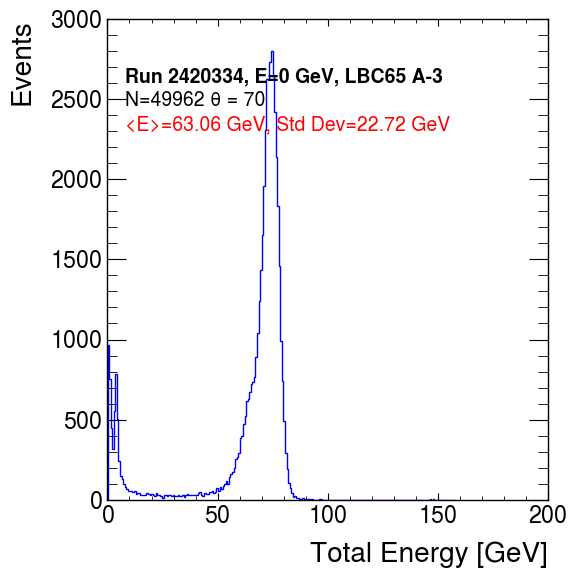

In [350]:
# Draw initial distributions
fig, ax = plt.subplots(figsize=(6,6))
initial_reco_energy, initial_indices = helpers.reco_energy(h1000=run, modules=config['modules']['total_energy'], cell=None, events=None, return_indices=True)
initial_reco_energy = initial_reco_energy / 1000 # to GeV
plt.hist(initial_reco_energy, bins=int(np.sqrt(len(initial_reco_energy))), histtype='step', color='blue')
ax.text(x=0.04, y=0.9, s=f'Run {run_number}, E={energy/1000 :.0f} GeV, {hit_cell}', transform=ax.transAxes, verticalalignment='top', weight='bold')
ax.text(x=0.04, y=0.85, s=f'N={len(initial_reco_energy)} θ = {angle}', transform=ax.transAxes, verticalalignment='top', weight='ultralight')
ax.text(x=0.04, y=0.80, s=f'<E>={initial_reco_energy.mean():.2f} GeV, Std Dev={initial_reco_energy.std():.2f} GeV', transform=ax.transAxes, verticalalignment='top', weight='ultralight', color='r')
plt.xlabel('Total Energy [GeV]')
plt.ylabel('Events')
# cell energy < 60 MeV are removed so the total #of events < original #of events
initial_plot_path = f"{results_dir}/initial_distro/{energy}GeV/"
os.makedirs(initial_plot_path, exist_ok=True)
print(f"Plots will be saved in {initial_plot_path} \n")
plt.tight_layout()
plt.savefig(f"{initial_plot_path}/{run_number}_angle{angle}_E.pdf", dpi=150)

(18, 50038)
(49962,)


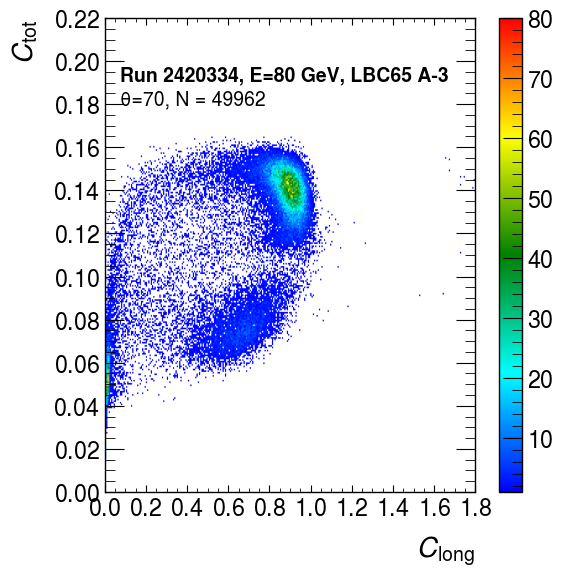

In [351]:
# clong / ctot initial
clong_initial = helpers.ParticleSeparator(h1000=run).compute_clong(cell=center_cell, beam_energy=energy*1000, events=initial_indices) #if events=None, use all events
ctot_initial = helpers.ParticleSeparator(h1000=run).compute_ctot(cell=center_cell, events=initial_indices)
fig, ax, N = helpers.root_like_histogram(x=clong_initial, y=ctot_initial, xmin=0, xmax=1.8, ymin=0, ymax=0.22, n_xbins=300, n_ybins=300, x_inc=0.2, y_inc=0.02)

ax.text(x=0.04, y=0.9, s=f'Run {run_number}, E={energy :.0f} GeV, {hit_cell}', transform=ax.transAxes, verticalalignment='top', weight='bold')
ax.text(x=0.04, y=0.85, s=ang_txt +'=' +  str(angle) + f', N = {N}', transform=ax.transAxes, verticalalignment='top')

ax.set_xlabel('$C_{\\text{long}}$')
ax.set_ylabel('$C_{\\text{tot}}$')
fig.tight_layout()
fig.savefig(f"{initial_plot_path}/{run_number}_angle{angle}_ctot_clong.pdf", dpi=150)

In [352]:
# start filtering particles
single_particles =  helpers.ParticleSeparator(h1000=run).single_particle_cut()
collimated_particles = helpers.ParticleSeparator(h1000=run).good_beam_trajectory()
muon_events = helpers.ParticleSeparator(h1000=run).muon_events()
df = run.arrays(library='pd')
single_set = set(single_particles)
collimated_set = set(collimated_particles)
muon_set = set(muon_events)
elec_had_ind = list(single_set.intersection(collimated_set).difference(muon_set))

Total events: 50038
Muon events: 4058 (8.1%)
Mean energy of muon events: 2674.1 MeV
Total events: 50038
S1 MPV (MIP): 2559.38
S2 MPV (MIP): 1771.88
Events passing cuts: 43742 (87.4%)
Total events: 50038
Events with good trajectory: 41834 (83.6%)
Beam center: x = -1.9136 mm, y = -2.9484 mm
Total events: 50038
Muon events: 4058 (8.1%)
Mean energy of muon events: 2674.1 MeV


In [353]:
final_plot_path = f"{results_dir}/final_distro/{energy}GeV/"
os.makedirs(final_plot_path, exist_ok=True)

(18, 50038)
(37486,)
(18, 50038)
(26199,)


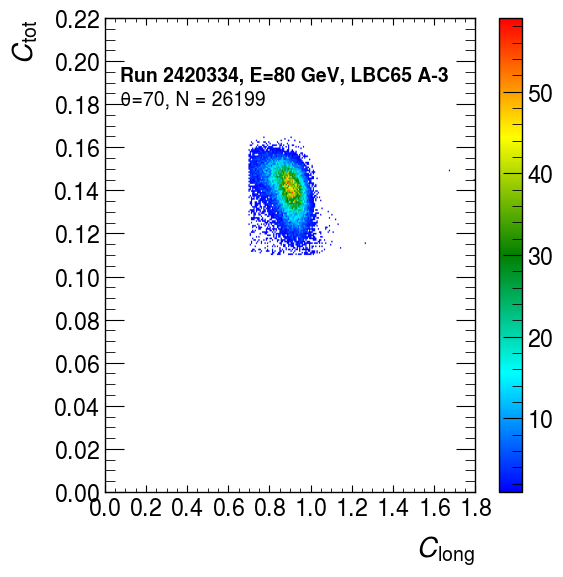

In [354]:
# energy distribution after shower variables cut

a, b = config['elliptical_cuts'][angle][0]
h, k = config['elliptical_cuts'][angle][1]

clong_el_had = helpers.ParticleSeparator(h1000=run).compute_clong(cell=center_cell, beam_energy=energy*1000, events=elec_had_ind)
ctot_el_had = helpers.ParticleSeparator(h1000=run).compute_ctot(cell=center_cell, events=elec_had_ind)
if run_number == 2420301 or angle == 0:
    mask = (clong_el_had > 0.5) & (ctot_el_had > 0.10)
    electron_indices = np.array(elec_had_ind)[mask]
elif run_number == 2420302 or angle == 5:
    mask = (clong_el_had > 0.4) & (ctot_el_had > 0.11)
    electron_indices = np.array(elec_had_ind)[mask]
elif run_number == 2420309 or angle == 10:
    mask = (clong_el_had > 0.6) & (ctot_el_had > 0.11)
    electron_indices = np.array(elec_had_ind)[mask]
elif run_number == 2420310 or angle == 20:
    mask = (clong_el_had > 0.7) & (ctot_el_had > 0.12)
    electron_indices = np.array(elec_had_ind)[mask]
elif run_number == 2420319 or angle == 30:
    mask = (clong_el_had > 0.7) & (ctot_el_had > 0.125)
    electron_indices = np.array(elec_had_ind)[mask]
elif run_number == 2420320 or angle == 40:
    mask = (clong_el_had > 0.8) & (ctot_el_had > 0.12)
    electron_indices = np.array(elec_had_ind)[mask]
elif run_number == 2420327 or angle == 50:
    mask = (clong_el_had > 0.8) & (ctot_el_had > 0.11)
    electron_indices = np.array(elec_had_ind)[mask]
elif run_number == 2420328 or angle == 60:
    mask = (clong_el_had > 0.8) & (ctot_el_had > 0.10)
    electron_indices = np.array(elec_had_ind)[mask]
elif run_number == 2420335 or angle == 70:
    mask = (clong_el_had > 0.7) & (ctot_el_had > 0.11)
    electron_indices = np.array(elec_had_ind)[mask]
else:
    electron_indices = helpers.ParticleSeparator(h1000=run).pure_electron_events(cell='A3', ctot=ctot_el_had, clong=clong_el_had, elec_had_indices=elec_had_ind, ellipse_axes=(a, b), ellipse_center=(h, k))

el_ctot = helpers.ParticleSeparator(h1000=run).compute_ctot(cell='A3', events=electron_indices)
el_clong = helpers.ParticleSeparator(h1000=run).compute_clong(cell='A3', beam_energy=energy*1000, events=electron_indices)
fig, ax, N = helpers.root_like_histogram(x=el_clong, y=el_ctot, xmin=0, xmax=1.8, ymin=0, ymax=0.22, n_xbins=300, n_ybins=300, x_inc=0.2, y_inc=0.02)

ax.text(x=0.04, y=0.9, s=f'Run {run_number}, E={energy :.0f} GeV, {hit_cell}', transform=ax.transAxes, verticalalignment='top', weight='bold')
ax.text(x=0.04, y=0.85, s=ang_txt +'=' +  str(angle) + f', N = {N}', transform=ax.transAxes, verticalalignment='top')

ax.set_xlabel('$C_{\\text{long}}$')
ax.set_ylabel('$C_{\\text{tot}}$')
fig.tight_layout()
fig.savefig(f"{final_plot_path}/{run_number}_angle{angle}_ctot_clong.pdf", dpi=150)

Used 4 modules from given 4 modules to compute energy


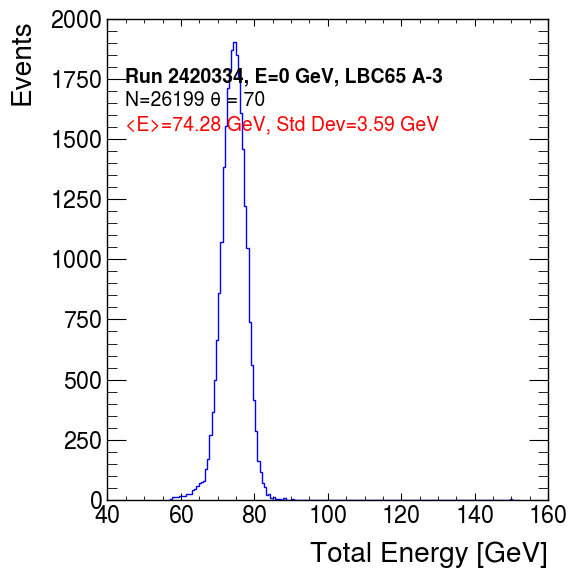

In [355]:
fig, ax = plt.subplots(figsize=(6,6))
final_reco_energy, final_indices = helpers.reco_energy(h1000=run, modules=config['modules']['total_energy'], cell=None, events=electron_indices, return_indices=True)
final_reco_energy = final_reco_energy / 1000 # to GeV
plt.hist(final_reco_energy, bins=int(np.sqrt(len(final_reco_energy))), histtype='step', color='blue')
ax.text(x=0.04, y=0.9, s=f'Run {run_number}, E={energy/1000 :.0f} GeV, {hit_cell}', transform=ax.transAxes, verticalalignment='top', weight='bold')
ax.text(x=0.04, y=0.85, s=f'N={len(final_reco_energy)} θ = {angle}', transform=ax.transAxes, verticalalignment='top', weight='ultralight')
ax.text(x=0.04, y=0.80, s=f'<E>={final_reco_energy.mean():.2f} GeV, Std Dev={final_reco_energy.std():.2f} GeV', transform=ax.transAxes, verticalalignment='top', weight='ultralight', color='r')
plt.xlabel('Total Energy [GeV]')
plt.ylabel('Events')
plt.tight_layout()
plt.savefig(f"{final_plot_path}/{run_number}_angle{angle}_E.pdf", dpi=150)